In [1]:
from pathlib import Path

import pandas as pd

from chef_classifier.data import (
    clean_training_data,
    create_train_val_split,
    load_training_data,
)

In [2]:
PROJECT_ROOT = Path("..")
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test-no-labels.csv"

In [3]:
train = load_training_data(TRAIN_PATH)
test = pd.read_csv(TEST_PATH, sep=";")

In [4]:
train.head()

,chef_id,recipe_name,data,tags,steps,description,ingredients,n_ingredients
0,5060,chefy s rice pudding,29/01/2002,"['60-minutes-or-less', 'time-to-make', 'course...","['cook rice according to package directions', ...","by request, from georgian bay gourmet.","['long grain rice', 'half-and-half cream', 'eg...",6
1,3288,lasagna in the pressure cooker,14/12/2016,"['30-minutes-or-less', 'time-to-make', 'course...","['in the opened pressure cooker , add the oil ...",i love how quickly i can put together a meal i...,"['olive oil', 'onion', 'ground beef', 'pasta s...",13
2,5060,ham frittata,22/09/2004,"['60-minutes-or-less', 'time-to-make', 'course...","['heat oven to 400f', 'heat oil in a non stick...",great for a quick meal with left over ham! lot...,"['olive oil', 'cooked ham', 'onion', 'red swee...",12
3,1533,red pepper garlic sauce,12/04/2005,"['15-minutes-or-less', 'time-to-make', 'course...",['in a small mixing bowl mix all above ingredi...,this was so nice on salmon and we also have tr...,"['red peppers', 'garlic cloves', 'mayonnaise',...",4
4,5060,simple easy stuffed roast chicken with gravy ...,14/10/2004,"['time-to-make', 'course', 'main-ingredient', ...","['preheat oven to 400f', 'empty contents of st...",this method can be used for roast chicken or t...,"['chicken flavor stuffing mix', 'hot water', '...",13


In [5]:
train.shape, test.shape

((2999, 8), (823, 7))

In [6]:
train.columns.tolist(), test.columns.tolist()

(['chef_id',
  'recipe_name',
  'data',
  'tags',
  'steps',
  'description',
  'ingredients',
  'n_ingredients'],
 ['recipe_name',
  'data',
  'tags',
  'steps',
  'description',
  'ingredients',
  'n_ingredients'])

In [7]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   chef_id        2999 non-null   int64
 1   recipe_name    2999 non-null   str  
 2   data           2999 non-null   str  
 3   tags           2999 non-null   str  
 4   steps          2999 non-null   str  
 5   description    2999 non-null   str  
 6   ingredients    2999 non-null   str  
 7   n_ingredients  2999 non-null   int64
dtypes: int64(2), str(6)
memory usage: 187.6 KB


In [8]:
train["chef_id"].value_counts()

chef_id
4470    806
5060    534
3288    451
8688    432
1533    404
6357    372
Name: count, dtype: int64

In [9]:
train["chef_id"].value_counts(normalize=True)

chef_id
4470    0.268756
5060    0.178059
3288    0.150383
8688    0.144048
1533    0.134712
6357    0.124041
Name: proportion, dtype: float64

<Axes: title={'center': 'Number of recipes per chef'}, xlabel='Chef ID', ylabel='Number of recipes'>

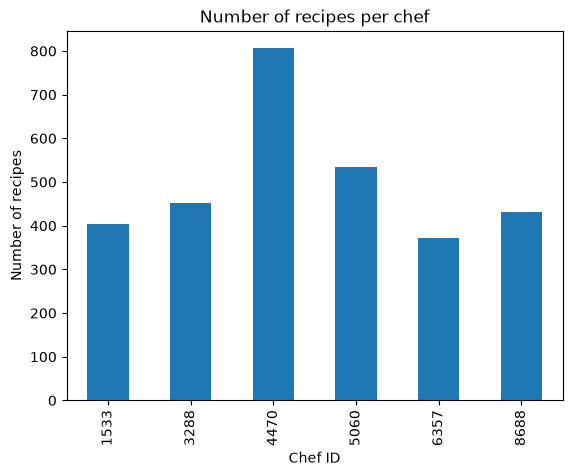

In [10]:
train["chef_id"].value_counts().sort_index().plot(
    kind="bar",
    title="Number of recipes per chef",
    xlabel="Chef ID",
    ylabel="Number of recipes",
)

In [11]:
train.isna().sum()

chef_id          0
recipe_name      0
data             0
tags             0
steps            0
description      0
ingredients      0
n_ingredients    0
dtype: int64

In [12]:
test.isna().sum()

recipe_name      0
data             0
tags             0
steps            0
description      0
ingredients      0
n_ingredients    0
dtype: int64

In [13]:
text_columns = [
    "recipe_name",
    "tags",
    "steps",
    "description",
    "ingredients",
]

for col in text_columns:
    print(
        col,
        "avg chars:",
        train[col].str.len().mean(),
        "median chars:",
        train[col].str.len().median(),
    )

recipe_name avg chars: 28.33244414804935 median chars: 27.0
tags avg chars: 333.3464488162721 median chars: 329.0
steps avg chars: 539.5495165055019 median chars: 478.0
description avg chars: 155.16005335111703 median chars: 119.0
ingredients avg chars: 138.56618872957654 median chars: 131.0


In [14]:
for col in [
    "recipe_name",
    "description",
    "ingredients",
    "steps",
    "tags",
]:
    train[f"{col}_length"] = train[col].str.len()

train.groupby("chef_id")[
    [
        "recipe_name_length",
        "description_length",
        "ingredients_length",
        "steps_length",
        "tags_length",
    ]
].mean().round(1)

,recipe_name_length,description_length,ingredients_length,steps_length,tags_length
chef_id,,,,,
1533,26.8,80.7,124.5,433.2,318.3
3288,28.6,141.7,148.9,574.9,363.7
4470,28.2,214.0,126.6,467.8,320.0
5060,27.1,104.4,153.5,639.5,410.5
6357,31.3,191.3,143.6,599.2,332.2
8688,28.7,160.6,140.4,561.0,246.3


In [15]:
train.groupby("chef_id")["n_ingredients"].describe()

,count,mean,std,min,25%,50%,75%,max
chef_id,,,,,,,,
1533,404.0,8.049505,2.995037,2.0,6.0,8.0,10.0,19.0
3288,451.0,9.541020,3.675744,2.0,7.0,9.0,12.0,27.0
4470,806.0,8.490074,3.224021,2.0,6.0,8.0,10.0,21.0
5060,534.0,9.855805,3.467863,2.0,7.0,9.0,12.0,26.0
6357,372.0,9.948925,4.938989,2.0,6.0,9.0,13.0,36.0
8688,432.0,8.902778,3.671524,2.0,6.0,8.0,11.0,23.0


In [16]:
train.nunique()

chef_id                  6
recipe_name           2985
data                  1045
tags                  2976
steps                 2979
description           2959
ingredients           2985
n_ingredients           25
recipe_name_length      63
description_length     499
ingredients_length     293
steps_length          1062
tags_length            477
dtype: int64

In [17]:
train.duplicated().sum()

np.int64(14)

In [18]:
for col in [
    "recipe_name",
    "description",
    "ingredients",
    "steps",
    "tags",
]:
    print(col, train[col].duplicated().sum())

recipe_name 14
description 40
ingredients 14
steps 20
tags 23


In [19]:
duplicate_names = train[
    train["recipe_name"].duplicated(keep=False)
].sort_values("recipe_name")

duplicate_names[
    ["chef_id", "recipe_name", "description", "ingredients"]
]

,chef_id,recipe_name,description,ingredients
955,1533,beef and macaroni chili,leftovers are good reheated the next day and c...,"['macaroni', 'ground beef', 'garlic powder', '..."
138,1533,beef and macaroni chili,leftovers are good reheated the next day and c...,"['macaroni', 'ground beef', 'garlic powder', '..."
1957,1533,beef and macaroni chili,leftovers are good reheated the next day and c...,"['macaroni', 'ground beef', 'garlic powder', '..."
616,6357,charishma s amazing chole delight,this recipe was passed on to me from my mom wh...,"['onions', 'black channa', 'ginger', 'garlic',..."
1653,6357,charishma s amazing chole delight,this recipe was passed on to me from my mom wh...,"['onions', 'black channa', 'ginger', 'garlic',..."
751,4470,green bean tomato anaheim peppers,when the garden abounds you need to get a bit ...,"['fresh green beans', 'cherry tomatoes', 'anah..."
984,4470,green bean tomato anaheim peppers,when the garden abounds you need to get a bit ...,"['fresh green beans', 'cherry tomatoes', 'anah..."
1440,4470,green bean tomato anaheim peppers,when the garden abounds you need to get a bit ...,"['fresh green beans', 'cherry tomatoes', 'anah..."
212,6357,grilled sweetcorn,this is,"['corn on the cob', 'butter', 'salt', 'pepper']"
319,6357,grilled sweetcorn,this is,"['corn on the cob', 'butter', 'salt', 'pepper']"


In [20]:
train["parsed_date"] = pd.to_datetime(
    train["data"],
    format="%d/%m/%Y",
)

train.groupby("chef_id")["parsed_date"].agg(["min", "max"])

,min,max
chef_id,,
1533,1999-08-06,2008-02-29
3288,2000-11-11,2016-12-14
4470,2001-04-22,2010-06-10
5060,2001-01-27,2009-09-28
6357,2001-03-14,2015-07-30
8688,2000-03-13,2012-06-18


In [21]:
train["year"] = train["parsed_date"].dt.year

pd.crosstab(
    train["year"],
    train["chef_id"],
)

chef_id,1533,3288,4470,5060,6357,8688
year,,,,,,
1999,56,0,0,0,0,0
2000,0,1,0,0,0,1
2001,0,8,242,123,71,0
2002,128,227,320,255,90,133
2003,82,117,79,61,130,152
2004,56,31,80,39,52,15
2005,71,42,37,15,9,18
2006,3,13,20,16,12,26
2007,3,10,4,12,3,72


In [22]:
train.groupby("chef_id")["year"].describe()

,count,mean,std,min,25%,50%,75%,max
chef_id,,,,,,,,
1533,404.0,2002.732673,1.951731,1999.0,2002.0,2003.0,2004.0,2008.0
3288,451.0,2002.931264,1.471861,2000.0,2002.0,2002.0,2003.0,2016.0
4470,806.0,2002.464020,1.720341,2001.0,2001.0,2002.0,2003.0,2010.0
5060,534.0,2002.496255,1.616921,2001.0,2002.0,2002.0,2003.0,2009.0
6357,372.0,2002.806452,1.626983,2001.0,2002.0,2003.0,2003.0,2015.0
8688,432.0,2003.849537,2.053360,2000.0,2002.0,2003.0,2006.0,2012.0


In [23]:
for col in ["recipe_name", "description", "ingredients", "tags"]:
    print(f"\n--- {col} ---")
    for value in train[col].sample(3, random_state=42):
        print(value[:500])
        print()


--- recipe_name ---
bbq balsamic cornish game hens

ginger icing  cream cheese frosting with candied ginger

hash browns  cabbage  n corned beef pie


--- description ---
quick easy recipe. the marinade gives a little boost to the flavor.

this recipe is posted in response to a request. i found it on www.recipesource.com

this is such a versatile dish - great for brunch, lunch or dinner. i like to top it off with grated cheddar or parmesan cheese . you may also try buttered crumbs on top or plain the way this recipe reads. garlic & jalapeños are optional i like a bit of zip. this could be vegetarian if you leave out the corned beef. i think of this as a base recipe that you can play with and use up a lot of left overs. put it together early in the day and just pop it in the oven 55 minutes before serving


--- ingredients ---
['cornish hens', 'garlic cloves', 'balsamic vinegar', 'lite olive oil', 'dried rosemary', 'hot pepper sauce', 'cumin', 'oregano', 'pepper']

['unsalted butter', 

In [24]:
train_clean = clean_training_data(train)
train_clean.shape

(2985, 15)

In [25]:
train_df, val_df = create_train_val_split(train_clean)

In [26]:
train_df["chef_id"].value_counts(normalize=True).sort_index()

chef_id
1533    0.134841
3288    0.151173
4470    0.268425
5060    0.178811
6357    0.122278
8688    0.144472
Name: proportion, dtype: float64

In [27]:
val_df["chef_id"].value_counts(normalize=True).sort_index()

chef_id
1533    0.134003
3288    0.150754
4470    0.268007
5060    0.179229
6357    0.122278
8688    0.145729
Name: proportion, dtype: float64

- The training set has 2999 recipes, the test set has 823 recipes.
- The training set has 8 columns, the test set has those same features except for the target variable chef_id (which contains 6 chef classes).
- The class distribution is moderately imbalanced (chef 4470 is the most frequent class with 26.9% of the training examples, chef 6357 is the least frequent with 12.4%)
- There are no missing values.

- Text features: recipe_name; tags; steps; description; ingredients.
- Numeric feature: n_ingredients. (This feature appears to vary a bit between chefs)
- Temporal feature: data

- There are 14 exact duplicate rows in the training set (we should remove them). Other text fields are also almost completely unique with a few exceptions: description has 40 duplicated values; tags has 23; steps has 20; ingredients has 14.

- The date distribution differ across chefs, which suggests that date-related information may have predictive value. However, date may reflect dataset collection patterns rather than genuine linguistic or culinary style, so it should be treated as a potentially dataset-specific feature and evaluated separately.

- The average number of ingredients and text lengths also varies somewhat between chefs, suggesting that stylistic features beyond vocabulary may contain useful information.



- For validation: exact duplicated were removed; the remaining data was split into 80% training and 20% validation; this split was stratified by chef_id, ensuring more or less the same class distribution in both subsets.